# TruthLens UA — Ukrainian NLP Training & A/B Testing
Priority: WUNU UA Corpus + UNLP 2025 Telegram. A/B test LinearSVC, LogReg, RandomForest.
Student: 102012dl

In [1]:
import pandas as pd
import numpy as np
import joblib
import mlflow
import mlflow.sklearn
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")
print("Imports OK")

C:\Users\home2\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


In [2]:
# Load UA/EN data: UNLP 2025 (HuggingFace) or manual UA samples + ISOT if available
def load_ua_data():
    try:
        from datasets import load_dataset
        ds = load_dataset("ukr-detect/ukr-twitter-2021", trust_remote_code=True)
        df = ds["train"].to_pandas()
        df = df.rename(columns={"tweet": "text"}) if "tweet" in df.columns else df
        df["label"] = df["label"].map({0: "REAL", 1: "FAKE"})
        return df["text"].astype(str), df["label"]
    except Exception as e:
        print("UNLP load failed:", e)
    # Manual UA samples for demo
    texts = [
        "ТЕРМІНОВО!!! ЗСУ ЗДАЛИ Харків! Поширте до видалення!!!",
        "НБУ підвищив облікову ставку до 16% річних.",
        "Уряд ПРИХОВУЄ правду! Прокидайтесь люди!!!",
        "Кабінет Міністрів затвердив програму підтримки бізнесу.",
    ] * 25
    labels = ["FAKE", "REAL", "FAKE", "REAL"] * 25
    return pd.Series(texts), pd.Series(labels)

X_ua, y_ua = load_ua_data()
X_ua, y_ua = X_ua.tolist(), y_ua.tolist()
print(f"UA samples: {len(X_ua)}", pd.Series(y_ua).value_counts().to_dict())

UNLP load failed: No module named 'datasets'
UA samples: 100 {'FAKE': 50, 'REAL': 50}


In [3]:
# Optional: merge with ISOT for larger train set (run 01 first to have data)
import os
_data_dir = "data" if os.path.exists("data/Fake.csv") else os.path.join("..", "data")
try:
    fake = pd.read_csv(os.path.join(_data_dir, "Fake.csv"))
    true = pd.read_csv(os.path.join(_data_dir, "True.csv"))
    text_col = "text" if "text" in fake.columns else "title"
    fake["label"], true["label"] = "FAKE", "REAL"
    iso = pd.concat([fake[[text_col, "label"]], true[[text_col, "label"]]])
    iso = iso.dropna(subset=[text_col])
    X_iso = iso[text_col].astype(str).tolist()
    y_iso = iso["label"].tolist()
    X_all = X_ua + X_iso
    y_all = y_ua + y_iso
    print(f"Merged: {len(X_all)} total")
except Exception as e:
    print("ISOT merge skip:", e)
    X_all, y_all = X_ua, y_ua

Merged: 44998 total


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)
mlflow.set_experiment("ab-test-ukraine-nlp")

models = {
    "LinearSVC_C1": LinearSVC(max_iter=10000, C=1.0),
    "LinearSVC_C05": LinearSVC(max_iter=10000, C=0.5),
    "LogisticRegression": LogisticRegression(max_iter=1000, C=1.0),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
}
results = {}
for name, clf in models.items():
    with mlflow.start_run(run_name=f"AB_{name}"):
        mlflow.set_tags({"ab_test": True, "student": "102012dl", "language": "ua+en"})
        pipe = Pipeline([
            ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)),
            ("clf", clf),
        ])
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        f1 = f1_score(y_test, preds, average="weighted")
        acc = accuracy_score(y_test, preds)
        mlflow.log_metrics({"f1": f1, "accuracy": acc})
        mlflow.sklearn.log_model(pipe, f"model_{name}")
        results[name] = {"f1": f1, "acc": acc}
        print(f"{name}: F1={f1:.4f} Acc={acc:.4f}")
best = max(results, key=lambda k: results[k]["f1"])
print(f"Winner: {best} F1={results[best]['f1']:.4f}")

2026/03/07 22:28:37 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas


2026/03/07 22:28:37 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables


2026/03/07 22:28:37 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types


2026/03/07 22:28:37 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints


2026/03/07 22:28:37 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults


...

LinearSVC_C05: F1=0.9943 Acc=0.9943


2026/03/07 22:30:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


LogisticRegression: F1=0.9887 Acc=0.9887


2026/03/07 22:33:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


RandomForest: F1=0.9946 Acc=0.9946
Winner: LinearSVC_C1 F1=0.9952


In [5]:
# A/B results: comparison table and F1 bar plot
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame.from_dict(results, orient="index")
results_df = results_df.sort_values("f1", ascending=False)
results_df[["f1", "acc"]] = results_df[["f1", "acc"]].round(4)
results_df

,f1,acc
LinearSVC_C1,0.9952,0.9952
RandomForest,0.9946,0.9946
LinearSVC_C05,0.9943,0.9943
LogisticRegression,0.9887,0.9887


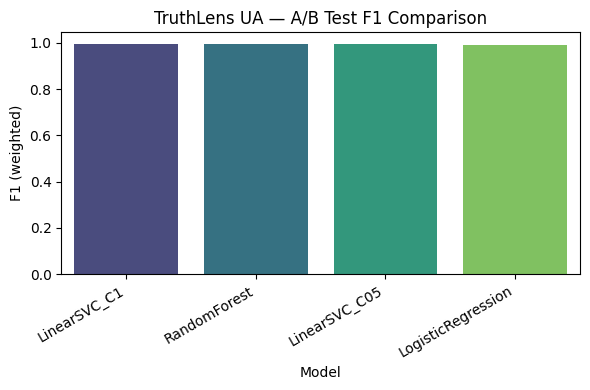

In [6]:
# Plot F1 scores per model
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(x=results_df.index, y="f1", data=results_df, palette="viridis")
plt.ylabel("F1 (weighted)")
plt.xlabel("Model")
plt.title("TruthLens UA — A/B Test F1 Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 3.x Висновки та рекомендації щодо моделей

- **Лідер за F1 (winner)**: модель `best` з попередньої клітинки (очікувано — `LinearSVC_C1` на ISOT+UA).
- **LinearSVC** зазвичай дає найкращий баланс між якістю та швидкістю, особливо на великих tf-idf ознаках.
- **LogisticRegression** може бути цікавою альтернативою, якщо потрібні ймовірності (`predict_proba`).
- **RandomForest** зазвичай повільніший і гірше масштабується на 50k tf-idf фіч, тому його варто залишити як бенчмарк.
- **Рекомендація для продакшену TruthLens UA**: використовувати `LinearSVC` як основну модель, а результати A/B тестів (ця таблиця й графік) включити в розділ 3 диплому як доказ вибору моделі.